##### **Objective:** Prepare the dataset for machine learning in a reproducible, leakage-free manner.
- All preprocessing decisions will be based on observations from previous phases (Data Understanding and EDA).

In [67]:
import pandas as pd 
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pandas.api.types import is_numeric_dtype
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin


In [34]:
# Load the raw train.csv and test.csv datasets
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

# Separate target and predictors and remove the SalePrice column from the feature matrix. 
y =train_df['SalePrice']
X = train_df.drop(columns="SalePrice") # Ensures readability


# Perform a train/validation split on the training data.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=None)

# 42 is a reference to Douglas Adams's The Hitchhiker's Guide to the Galaxy.

# shuffle = True ensures that the training and validation sets are representative of the overall dataset. It randomly picks 20% of rows from anywhere in the dataset (because shuffle=True is the default setting behind the scenes).


#Inspect the shapes
print(f"Training features: {X_train.shape}")
print(f"Validation features: {X_valid.shape}")
print(f"Training target: {y_train.shape}")
print(f"Validation target: {y_valid.shape}")



Training features: (1168, 80)
Validation features: (292, 80)
Training target: (1168,)
Validation target: (292,)


- Stratify must be kept none because stratification is designed for categorical classification targets (like predicting 1 or 0) to ensure each fold gets equal class proportions. But SalePrice is a continuous numeric variable (regression target). So it gies an error like: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [34900, 35311, 37900, ...]

- train_test_split attempts to preserve class proportions. Since every SalePrice is effectively unique, each value becomes its own class, making stratification impossible.

- `train_test_split(X, y, test_size=0.2, shuffle=False)`: Takes the bottom 20% of rows sequentially without shuffling.

In [35]:
#Veriffy split:
print("First few rows of X_train:")
X_train.head()

First few rows of X_train:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


In [36]:
print("First few rows of X_valid:")
X_valid.head()

First few rows of X_valid:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
892,893,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal
1105,1106,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
413,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal
522,523,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal
1036,1037,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,...,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal


# **Investigating and Handling Null Values**

## Deep Investigation into Suspecious Features:

In [37]:
train_df.loc[train_df["MasVnrArea"].isnull(), ["Id", "MasVnrType", "MasVnrArea"]]


,Id,MasVnrType,MasVnrArea
234,235,NaN,NaN
529,530,NaN,NaN
650,651,NaN,NaN
936,937,NaN,NaN
973,974,NaN,NaN
977,978,NaN,NaN
1243,1244,NaN,NaN
1278,1279,NaN,NaN


In [38]:
train_df.loc[(train_df["MasVnrArea"].notnull() & train_df["MasVnrType"].isnull()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
1,2,NaN,0.0
3,4,NaN,0.0
5,6,NaN,0.0
8,9,NaN,0.0
9,10,NaN,0.0
...,...,...,...
1454,1455,NaN,0.0
1455,1456,NaN,0.0
1457,1458,NaN,0.0
1458,1459,NaN,0.0


In [39]:
train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"].notnull()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
688,689,BrkFace,0.0
1241,1242,Stone,0.0


In [40]:
train_df.loc[(train_df["MasVnrArea"].isnull()) & (train_df["MasVnrType"].notnull()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea


In [41]:
train_df.loc[(train_df["Fireplaces"] == 0) & (train_df["FireplaceQu"].notnull()), ["Id", "Fireplaces", "FireplaceQu"]]

,Id,Fireplaces,FireplaceQu


In [42]:
train_df.loc[train_df["LotFrontage"] == 0]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [43]:
train_df.loc[(train_df["BsmtExposure"].isnull()) & (train_df["BsmtCond"].notnull()), ["Id", "BsmtCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtFinType1"]]

,Id,BsmtCond,BsmtExposure,BsmtFinType2,BsmtQual,BsmtFinType1
948,949,TA,NaN,Unf,Gd,Unf


In [44]:
train_df.loc[(train_df["BsmtFinType2"].isnull()) & (train_df["BsmtCond"].notnull()), ["Id", "BsmtCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtFinType1"]]

,Id,BsmtCond,BsmtExposure,BsmtFinType2,BsmtQual,BsmtFinType1
332,333,TA,No,NaN,Gd,GLQ


#### Handling Missing Values


In [45]:
# avoid GarageYrBlt, as if we replace missing value in it as 0, it will become outlier.
cat_structural_cols = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]
# "Needs further validation against MasVnrType."
num_structural_cols = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea', 
    'MasVnrArea'
]
cat_fill_dict = {col: 'None' for col in cat_structural_cols}
num_fill_dict = {col: 0 for col in num_structural_cols} 

structural_fill_dict = {**cat_fill_dict, **num_fill_dict}

X_train = X_train.fillna(value = structural_fill_dict)
X_valid = X_valid.fillna(value = structural_fill_dict)
test_df = test_df.fillna(value = structural_fill_dict)

In [46]:
# Remaining structural missingness
train_rem = X_train[cat_structural_cols + num_structural_cols].isnull().sum().sum()
valid_rem = X_valid[cat_structural_cols + num_structural_cols].isnull().sum().sum()
test_rem  = test_df[cat_structural_cols + num_structural_cols].isnull().sum().sum()

print(f"Remaining structural NaNs in X_train: {train_rem}")
print(f"Remaining structural NaNs in X_valid: {valid_rem}")
print(f"Remaining structural NaNs in test_df: {test_rem}")

Remaining structural NaNs in X_train: 0
Remaining structural NaNs in X_valid: 0
Remaining structural NaNs in test_df: 0


> **Note**: The handling of structural missingness was done mostly by using the competition documentation so that rules (example NaN means no pool) comes from external knowledge, not from the training distribution. This means this particular transformation is deterministic (i.e. it doesn't estimate anything from the data.) Such transformations does not have a fit stage.

**Deterministic/Rule Based Transformations:**
- Rename columns
- Parse dates
- Replace structural NaNs
- Convert units
- Strip whitespace

**Transformations where Data is Learned:**
- Mean imputation
- Median imputation
- StandardScaler
- PCA
- KNN Imputer
- Target Encoding

In [47]:
null_counts = X_train.isnull().sum()

null_counts[null_counts > 0]

LotFrontage    217
MasVnrType     683
Electrical       1
GarageYrBlt     64
dtype: int64

In [48]:
train_df.loc[(train_df["MasVnrArea"] > 0) & (train_df["MasVnrType"].isnull()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
624,625,NaN,288.0
773,774,NaN,1.0
1230,1231,NaN,1.0
1300,1301,NaN,344.0
1334,1335,NaN,312.0


## Handling Strategies:
**LotFrontage**: Mean is vulnerable to outliers, LotFrontage is right-skewed, so median is a more robust estimator. Training an imputer model is costly, complex, not reproducable. Dropping is not a good option, we may lose a lot of information. Lot frontage depends heavily on neighborhood and zoning. So neighborhood median is intuitive.  
<br>
**Electrical**: As only one row, so we can either drop it or use global mode imputation.  
<br>
**MasVnrType**: Very complicated. Instead of dropping the rows, we can impute MasVnrType using the most common not null veneer type (the Mode) for houses that actually have a veneer. For this we can use the global mode or use the grouping by Exterior1st.  
<br>
**GarageYrBlt**: Engineer new feature: Missing Garage, GarageAge is not good option as 0 will have two different meanings.

In [49]:
# Remove the display limit for columns, this is the global solution, but temporary is fine for our purpose
# pd.set_option('display.max_columns', None)
with pd.option_context('display.max_columns', None):
    display(train_df.loc[(train_df["MasVnrArea"] > 0) & (train_df["MasVnrType"].isnull())])


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
624,625,60,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,2Story,6,5,1972,1972,Gable,CompShg,VinylSd,VinylSd,NaN,288.0,TA,TA,CBlock,TA,TA,No,Rec,247,Unf,0,485,732,GasA,Gd,Y,SBrkr,1012,778,0,1790,1,0,1,2,4,1,TA,8,Min2,1,TA,Attchd,1972.0,RFn,2,484,TA,TA,Y,148,0,0,0,147,0,NaN,NaN,NaN,0,11,2006,WD,Normal,165150
773,774,20,RL,70.0,10150,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,5,1958,1958,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,1.0,TA,TA,CBlock,TA,TA,No,Rec,456,Unf,0,456,912,GasA,Ex,Y,FuseA,912,0,0,912,0,0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1958.0,RFn,1,275,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2007,COD,Normal,114500
1230,1231,90,RL,NaN,18890,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,RRAe,Duplex,1.5Fin,5,5,1977,1977,Shed,CompShg,Plywood,Plywood,NaN,1.0,TA,TA,CBlock,Gd,TA,No,GLQ,498,Rec,211,652,1361,GasA,Ex,Y,SBrkr,1361,1259,0,2620,0,0,2,2,4,2,TA,12,Typ,1,TA,BuiltIn,1977.0,RFn,2,600,TA,TA,N,155,24,145,0,0,0,NaN,NaN,Gar2,8300,8,2007,WD,Normal,190000
1300,1301,60,RL,NaN,10762,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Gilbert,Norm,Norm,1Fam,2Story,7,5,1999,1999,Gable,CompShg,VinylSd,VinylSd,NaN,344.0,Gd,TA,PConc,Gd,TA,No,GLQ,694,Unf,0,284,978,GasA,Ex,Y,SBrkr,1005,978,0,1983,0,0,2,1,3,1,Gd,9,Typ,1,TA,Attchd,1999.0,Fin,2,490,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,225000
1334,1335,160,RM,24.0,2368,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,TwnhsE,2Story,5,6,1970,1970,Gable,CompShg,HdBoard,HdBoard,NaN,312.0,TA,TA,CBlock,TA,TA,No,LwQ,765,Unf,0,0,765,GasA,TA,Y,SBrkr,765,600,0,1365,0,0,1,1,3,1,TA,7,Min1,0,NaN,Attchd,1970.0,Unf,2,440,TA,TA,Y,0,36,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,125000


- Masonry: Building with stone, brick, or concrete blocks.

- Veneer: A thin, decorative layer attached to a surface (like a sticker or cover).

Masonry Veneer is basically a decorative, non-structural outer layer of brick, stone, or cinder block attached to the outside of a house.

Exterior1st / Exterior2nd: Represents the main structural covering of the house (e.g., VinylSd for vinyl siding, Wd Sdng for wood siding so on).

MasVnrType: Represents extra brick or stone layers added on top of or alongside the exterior walls (often around the front entrance, lower skirt, or chimney). Tt tells what material is the veneer? (BrkFace = face brick, Stone = decorative stone, None = no extra brick/stone).

- Exterior1st is the Primary Material as it covers the vast majority of the house. Exterior is the primary material covering 90% of the walls, while Masonry Veneer is an extra decorative brick/stone patch added over a portion of the front wall or porch. So they are a bit related! 

MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone

In [50]:
null_counts = train_df.isnull().sum()

null_counts[null_counts > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

# Building Custom Imputer (MedianImputer for a single numerical column)

In [51]:
#from pandas.api.types import is_numeric_dtype
# CUstom Imputer: MedianImputer for a single numerical column.
class MedianImputer:
    # Learned class attribute.
    def __init__(self):
        self.median_ = np.nan # The underscore distinguishes learned attributes from constructor parameters.
    def fit(self, X):
        # check whether the incoming Series or array is numeric using pandas.api.types.is_numeric_dtype()
        if not is_numeric_dtype(X):
            raise TypeError(
                "Imputer expects a numeric column"
            )
        self.col_median = X.median()
        return self # for method chaining: MedianImputer().fit(X).transform(X)
    def transform(self, X):
        if self.col_median is None:
            raise ValueError(
                "MedianImputer must be fitted before calling transform()."
            )
        return X.fillna(self.col_median)


> **Note 1**: In scikit-learn, attributes ending with an underscore (like self.col_median_) explicitly signify that the variable was learned during fit() rather than set by the user during initialization

> **Note 2**: Scikit-learn transformers expect a 2D array/DataFrame as input

> **Note 3**: In Jupyter Notebooks, calling a DataFrame line like X_train.loc[...] without print() only displays if it is the very last line in the cell.

> **Note 4**: In Python, DataFrames are passed into functions by reference (they point to the exact same memory location).

In [52]:
#from sklearn.impute import SimpleImputer
electrical_imputer = SimpleImputer(strategy='most_frequent')
electrical_imputer.fit(X_train[["Electrical"]])

X_train['Electrical'] = electrical_imputer.transform(X_train[['Electrical']])[:, 0] # all row, 0th columm
# instead of [:,0] we can use .ravel() also or even .squeeze()


In [53]:
#from sklearn.base import BaseEstimator, TransformerMixin

# TransformerMixin it automatically writes the fit_transform() method for the class. Else we would have to write: 
# def fit_transform(self, X, y=None):
#    return self.fit(X, y).transform(X)

# BaseEstimator connects your custom object to the rest of the scikit-learn ecosystem (like Pipeline, GridSearchCV, and RandomizedSearchCV).

class NeighborhoodLotFrontageImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.global_median_ = np.nan # Avoid program crashing during mathematical operation
        self.group_median_ =np.nan # To handle unseen Neighbourhood category

    def fit(self, X):
        # Learn group medians on training data
        self.global_median_ = X['LotFrontage'].median()
        self.group_median_ = X.groupby('Neighborhood')['LotFrontage'].median()
        #print(self.group_median_.head(), end = "\n")
        return self # For chaining
        

    def transform(self, X):
        X = X.copy()
        # Needed AI assistance here:
        mapped_medians = X['Neighborhood'].map(self.group_median_).fillna(self.global_median_)
        #print(mapped_medians.head())
        X['LotFrontage'] = X['LotFrontage'].fillna(mapped_medians)
        return X

lot_imputer = NeighborhoodLotFrontageImputer()
lot_imputer.fit(X_train)
X_train = lot_imputer.transform(X_train)

X_train.loc[X_train['LotFrontage'].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [54]:
def get_first_mode(series):
    modes = series.mode()
    if not modes.empty:
        return modes[0]
    return None

class Exterior1stMasVnrTypeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.global_mode_ = None
        self.group_mode_ = None

    def fit(self, X):
        # Global mode among homes that actually have veneer
        veneer_homes = X[X['MasVnrArea'] > 0]

        if not veneer_homes['MasVnrType'].dropna().empty:
            self.global_mode_ = veneer_homes["MasVnrType"].mode()[0]
        else:
            self.global_mode_ = X["MasVnrType"].mode()[0]

        self.group_mode_ = veneer_homes.groupby('Exterior1st')['MasVnrType'].apply(get_first_mode)

        return self

    def transform(self, X):
        X = X.copy()

        mapped_mode = X['Exterior1st'].map(self.group_mode_).fillna(self.global_mode_)

        X.loc[(X['MasVnrArea'] > 0), 'MasVnrType'] = X.loc[(X['MasVnrArea'] > 0), 'MasVnrType'].fillna(mapped_mode)
        
        return X

masvnrtype_imputer = Exterior1stMasVnrTypeImputer()
masvnrtype_imputer.fit(X_train)

X_train = masvnrtype_imputer.transform(X_train)
    

In [55]:
null_counts = X_train.isnull().sum()

null_counts[null_counts > 0]

MasVnrType     678
GarageYrBlt     64
dtype: int64

In [56]:
X_train.loc[(X_train["MasVnrArea"] > 0) & (X_train["MasVnrType"].isnull()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea


In [57]:
train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"].notnull()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
688,689,BrkFace,0.0
1241,1242,Stone,0.0


> **Note**: How to handle the above case? I think we must go back to the place where the data was collected to clear the ambuigity. Here for ease I am replacing the MAsVnrType as NaN.

In [58]:
# Handle the anomaly (Area is 0, but Type was given)
X_train.loc[
    (X_train['MasVnrArea'] == 0) & (X_train['MasVnrType'].notnull()),
    'MasVnrType'
] = 'None'


X_train['MasVnrType'] = X_train['MasVnrType'].fillna('None')


X_train.isnull().sum()[X_train.isnull().sum() > 0]

GarageYrBlt    64
dtype: int64

### NOTE:
 - Learned imputations are currently demonstrated on X_train only.
 - These transformations will later be incorporated into a
 - scikit-learn Pipeline and automatically applied to
 - X_valid and test_df using transform().

# **Feature Engineering**

In [59]:
with pd.option_context('display.max.columns', None):
    display(X_train.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,None,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,None,None,None,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,None,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,None,None,None,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,Wd Sdng,None,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,None,None,NaN,None,0,0,None,None,P,328,0,164,0,0,0,None,MnPrv,None,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,None,MnPrv,None,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,Wd Sdng,None,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,None,None,None,0,5,2010,WD,Normal


## Feature Engineering Design

| New Feature       | Formula                                | Why?                                              | Keep Original? | Will this feature still make sense on unseen future data?| Does it encode a concept a model can naturally learn? | Is this information already present elsewhere? | Could this introduce ambiguity? |
| ----------------- | -------------------------------------- | ------------------------------------------------- | -------------- | --- | --- | --- | --- |
| HouseAge          | `YrSold - YearBuilt`                   | Easier for models to interpret than absolute year | No             | Yes | Yes | No | No |
| GarageAge         | `YrSold - GarageYrBlt`                 | Represents garage age                             | No             | Yes | Yes | No | Yes, the garage may be absent |
| HasGarage         | `GarageType != "None"`                 | Separates absence from age                        | Yes            | Yes | Yes | No | No |
| YearsSinceRemodel | `YrSold - YearRemodAdd`                | Recency of renovation                             | No             | Yes | Yes | No | Yes if never remodelled |
| Remodeled         | `YearBuilt != YearRemodAdd`            | Whether renovation occurred                       | No             | Yes | Yes | No | Yes if never remodelled | 
|YearsUntilFirstRemodel| `YearRemodAdd - YearBuilt`          | Time until first remodelling                      | No             | Yes | Yes | Perhaps Yes, may cause redundancy  | Yes if never remodelled | 
| TotalBathrooms| `BsmtFullBath + (0.5 * BsmtHalfBath) + FullBath + (0.5 * HalfBath)` | Total bathroooms in whole house, HalfBath have less value than FullBath | Yes | Yes | Yes | No | No |
| TotalPorch | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF` | Total outdoor living area available | Yes | Yes | Yes | No | No |
| TotalUsableSF | `TotalBsmtSF + GrLivArea` | Total usable living area | Yes | Perhaps No | Yes | No | No |
| OverallScore | `OverallQual * OverallCond` | A house with high overall quality of material used but low overall condition may decrease the house value | Yes | Yes | Yes | No | No |
| BsmtFinishedRatio | `(BsmtFinSF1 + BsmtFinSF2)/ TotalBsmtSF` | Directly tells total useable Basement area | Yes | Yes | Yes | No | Maybe no if the house does not have basement | 
| OverallQual_x_TotalSF | `OverallQual * TotalSF` | Indicate Luxuory with size | Yes | Yes | Yes | No | No |
| AvgRoomSize | `GrLivArea/TotRmsAbvGrd` | Average room size above ground | Yes | Yes | Yes | No | Perhaps if the house only has basement | 
| TotalRoomsIncludingBathrooms | `TotRmsAbvGrd + FullBath + HalfBath` |  Indicates total number of rooms including bathroom | Yes | Yes | Yes | Yes, this can be redundant information | No | 
| PrimaryAmenityScore | `(CentralAir == 'Y') + HasGarage + (Fireplaces > 0) + (PoolQC != 'None') + (Utilities = 'AllPub) + (BsmtQual != 'None') + (Heating != 'None') + (Fence != 'None')` | Essential eminities provided |  Yes | Yes | Yes | No | No |  
| Lot_Accessability | `Combination of Street, Alley, PavedDrive ` | Indicate the house accessibility through roads, but i am not sure of appropriate formula | Yes | Yes | Yes | No | No |  




### **Feature Engineering Design Document**

#### Temporal Features
- HouseAge, drop YearBuilt
- GarageAge
- YearsSinceRemodel

#### Structural Features (Binary values)
- HasGarage
- Remodeled (Perhaps)

#### Aggregations
- TotalBathrooms
- TotalUsableSF 
- TotalPorch (Perhaps)

#### Ratios
- AvgRoomSize (Perhaps)
- BsmtFinishedRatio 

#### Interaction Features
- OverallScore (Perhaps)
- OverallQual × TotalSF
...
#### Features Rejected or Later Used
- YearsUntilFirstRemodel (Many house with same time say 10 does not give useful information.)
- TotalRoomsIncludingBathrooms (Redundant information)
- PrimaryAmenityScore (Perhaps, because many people have different notion of good amenity, better if we can add weights)
- Lot_Accessibility (Great but complicated implementation)

In [81]:
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']


X_train['GarageAge'] = X_train['YrSold'] - X_train['GarageYrBlt'] # Any Number - NaN = NaN
X_train['GarageAge'] = X_train['GarageAge'].fillna(0) # Double meaning of 0 resolved by HasGarage

X_train['HasGarage'] = (X_train['GarageType'] != "None").astype(int) # We replaced values with "None"


X_train['HasBsmt'] = (X_train['TotalBsmtSF'] > 0).astype(int)


X_train['YearsSinceRemodel'] = X_train['YrSold'] - X_train['YearRemodAdd']



X_train['TotalBathrooms'] = X_train['BsmtFullBath'] + (0.5 * X_train['BsmtHalfBath']) + X_train['FullBath'] + (0.5 * X_train['HalfBath'])



X_train['TotalUsableSF'] = X_train['GrLivArea'] + X_train['TotalBsmtSF']


X_train['BsmtFinishedRatio'] = np.where(
    X_train['TotalBsmtSF'] == 0, 
    0, 
    (X_train['BsmtFinSF1'] + X_train['BsmtFinSF2']) / X_train['TotalBsmtSF']
)



X_train['OverallQual_x_TotalUsableSF'] = X_train['OverallQual'] * X_train['TotalUsableSF']


X_train = X_train.drop(columns=['YearBuilt'])

# Got to know new thing: np.where(condition, if_true, if_false)

In [89]:
new_cols = [
    'HouseAge', 'HasGarage', 'GarageAge', 'YearsSinceRemodel',
    'TotalBathrooms', 'TotalUsableSF', 'BsmtFinishedRatio', 
    'OverallQual_x_TotalUsableSF', 'HasBsmt'
]

# Check for NaNs or Infinite values in newly created columns
print("Missing values in engineered columns:")
print(X_train[new_cols].isnull().sum())

print("\n\nInfinite values in engineered columns:")
print(np.isinf(X_train[new_cols]).sum())

print("\nSample values:")
X_train[new_cols].head()

Missing values in engineered columns:
HouseAge                       0
HasGarage                      0
GarageAge                      0
YearsSinceRemodel              0
TotalBathrooms                 0
TotalUsableSF                  0
BsmtFinishedRatio              0
OverallQual_x_TotalUsableSF    0
HasBsmt                        0
dtype: int64


Infinite values in engineered columns:
HouseAge                       0
HasGarage                      0
GarageAge                      0
YearsSinceRemodel              0
TotalBathrooms                 0
TotalUsableSF                  0
BsmtFinishedRatio              0
OverallQual_x_TotalUsableSF    0
HasBsmt                        0
dtype: int64

Sample values:


,HouseAge,HasGarage,GarageAge,YearsSinceRemodel,TotalBathrooms,TotalUsableSF,BsmtFinishedRatio,OverallQual_x_TotalUsableSF,HasBsmt
254,53,1,53.0,53,2.0,2628,0.701674,13140,1
1066,16,1,16.0,15,2.5,2370,0.000000,14220,1
638,98,0,0.0,58,1.0,1592,0.000000,7960,1
799,70,1,68.0,57,2.5,2499,0.778386,12495,1
380,86,1,86.0,60,2.0,2717,0.212476,13585,1


<Axes: xlabel='GarageAge', ylabel='Count'>

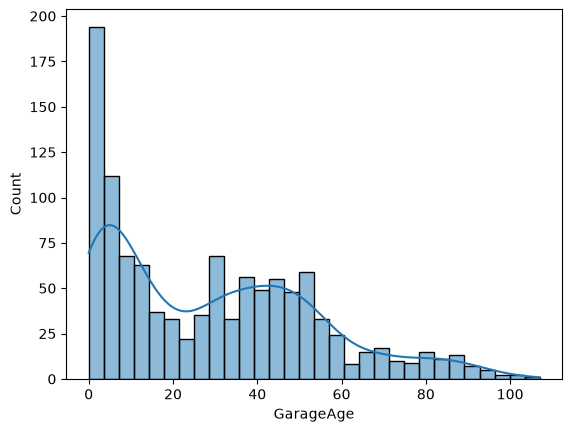

In [70]:
sns.histplot(X_train['GarageAge'], kde=True, bins=30)

#### 1. Ordinal

* **Columns:** `OverallQual`, `OverallCond`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `GarageQual`, `GarageCond`, `PoolQC`, `Fence`, `GarageFinish`, `LotShape`, `LandSlope`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `Utilities`, `Functional`, `PavedDrive`
* **Type:** Ordinal
* **Encoding:** Ordinal Encoding (Example: `Ex`=5, `Gd`=4, `TA`=3, `Fa`=2, `Po`=1, `None`=0)
* **Scaling:** I do not know. (Does ordinal features need scaling, I have never heard of it?)
* **Keep?** Yes

#### 2. Nominal

* **Columns:** `MSZoning`, `Street`, `Alley`, `Neighborhood`, `Condition1`, `BldgType`, `HouseStyle`, `RoofStyle`, `Exterior1st`, `Foundation`, `GarageType`, `SaleType`, `SaleCondition`, `LotConfig`, `LandContour`, `Condition2`, `RoofMatl`, `Exterior2nd`, `MasVnrType`, `Heating`, `Electrical`,  `MiscFeatures`, `MSSubClass`
* **Type:** Nominal
* **Encoding:** One-Hot Encoding
* **Scaling:** No
* **Keep?** Yes 

#### 3. Candidate for removal after verification

* **Columns:** `YearBuilt`, `YrSold`, `YearRemodAdd`, `GarageYrBlt`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`, `FullBath`, `HalfBath`, `BsmtFullBath`, `BsmtHalfBath`
* **Type:** Numerical
* **Encoding:** None
* **Scaling:** N/A
* **Keep?** drop, till now only YearBuilt is dropped

#### 4. Continuous Numerical

* **Columns:** `LotFrontage`, `LotArea`, `MasVnrArea`, `BsmtUnfSF`, `GarageArea`, `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `ScreenPorch`, `3SsnPorch`, `PoolArea`, `MiscVal`, `GrLivArea`, `1stFlrSF`, `2ndFlrSF`, `TotalBsmtSF`, `LowQualFinSF`, `BsmtFinSF1`, `BsmtFinSF2`, `TotalUsableSF` *(Engineered)*, `BsmtFinishedRatio` *(Engineered)*, `OverallQual_x_TotalUsableSF` *(Engineered)*
* **Type:** Continuous Numerical
* **Encoding:** None
* **Scaling:** Yes (StandardScaler / RobustScaler / log-transforms)
* **Keep?** Yes

#### 5. Binary / Flag Features

* **Columns:** `CentralAir`, `HasGarage` *(Engineered)*, `HasBsmt` *(Engineered)*
* **Type:** Binary 
* **Encoding:** Binary Map (`Y`=1, `N`=0)
* **Scaling:** No
* **Keep?** Yes

#### 6. Discrete Numerical

* **Columns:** `TotalBathrooms` *(Engineered)*, `KitchenAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `BedroomAbvGr`, `MoSold`, `HalfBath`, `FullBath`, `BsmtFullBath`, `BsmtHalfBath`, `YrSold`, `GarageCars`
* **Type:** Discrete Numerical
* **Encoding:** No
* **Scaling:** Yes (May be)
* **Keep?** Yes 


#### 7. Elapsed-Time Features

* **Columns:** `HouseAge` *(Engineered)*, `YearsSinceRemodel` *(Engineered)*, `GarageAge` *(Engineered)*
* **Type:** Discrete Numerical
* **Encoding:** No
* **Scaling:** Yes (Because the values may become large so may need scaling for linear models)
* **Keep?** Yes


#### 8. Identifier

* **Columns:** `Id`
* **Type:** Discrete Numerical
* **Encoding:** No
* **Scaling:** No
* **Keep?** No

#### 9. Target

* **Columns:** `SalePrice`
* **Type:** Continuous Numerical
* **Encoding:** No
* **Scaling:** No
* **Keep?** No

In [93]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive